# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [14]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  3955k      0 --:--:--  0:03:47 --:--:-- 6498k


In [15]:
!rm SUSY.csv

rm: cannot remove 'SUSY.csv': No such file or directory


In [16]:
!gunzip SUSY.csv.gz

In [12]:
ls -lh

total 2.5G
-rw-r--r-- 1 root root 3.6K Feb 16 14:25  DATA3402_Lab3_Merge_Conflict_Guide.pdf
-rw-r--r-- 1 root root  56K Feb 16 14:25 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 2 root root 4.0K Feb 16 14:25  Lab.2/
drwxr-xr-x 3 root root 4.0K Feb 16 17:18  Lab.3/
drwxr-xr-x 3 root root 4.0K Feb 20 23:47  Lab.4/
-rw-r--r-- 1 root root  80K Mar 20 22:33  Lab.6.finished.ipynb
-rw-r--r-- 1 root root 944K Apr 28 12:19 'Lab.7 (1).ipynb'
-rw-r--r-- 1 root root  11K Apr 27 12:11 'Lab5 completed.ipynb'
drwxr-xr-x 2 root root 4.0K Feb 16 14:25  Labs.3/
-rw-r--r-- 1 root root 228M Apr 27 13:50  SUSY-small.csv
-rw-r--r-- 1 root root 2.3G Apr 27 13:48  SUSY.csv


The data is provided as a comma separated file.

In [13]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [14]:
!ls -lh

total 2.5G
-rw-r--r-- 1 root root 3.6K Feb 16 14:25  DATA3402_Lab3_Merge_Conflict_Guide.pdf
-rw-r--r-- 1 root root  56K Feb 16 14:25 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 2 root root 4.0K Feb 16 14:25  Lab.2
drwxr-xr-x 3 root root 4.0K Feb 16 17:18  Lab.3
drwxr-xr-x 3 root root 4.0K Feb 20 23:47  Lab.4
-rw-r--r-- 1 root root  80K Mar 20 22:33  Lab.6.finished.ipynb
-rw-r--r-- 1 root root 944K Apr 28 12:19 'Lab.7 (1).ipynb'
-rw-r--r-- 1 root root  11K Apr 27 12:11 'Lab5 completed.ipynb'
drwxr-xr-x 2 root root 4.0K Feb 16 14:25  Labs.3
-rw-r--r-- 1 root root 228M Apr 27 13:50  SUSY-small.csv
-rw-r--r-- 1 root root 2.3G Apr 27 13:48  SUSY.csv


We see that we have 5 million datapoints.

In [15]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [16]:
!head -500000 SUSY.csv > SUSY-small.csv

In [17]:
ls -lh

total 2.5G
-rw-r--r-- 1 root root 3.6K Feb 16 14:25  DATA3402_Lab3_Merge_Conflict_Guide.pdf
-rw-r--r-- 1 root root  56K Feb 16 14:25 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 2 root root 4.0K Feb 16 14:25  Lab.2/
drwxr-xr-x 3 root root 4.0K Feb 16 17:18  Lab.3/
drwxr-xr-x 3 root root 4.0K Feb 20 23:47  Lab.4/
-rw-r--r-- 1 root root  80K Mar 20 22:33  Lab.6.finished.ipynb
-rw-r--r-- 1 root root 944K Apr 28 12:19 'Lab.7 (1).ipynb'
-rw-r--r-- 1 root root  11K Apr 27 12:11 'Lab5 completed.ipynb'
drwxr-xr-x 2 root root 4.0K Feb 16 14:25  Labs.3/
-rw-r--r-- 1 root root 228M Apr 28 12:19  SUSY-small.csv
-rw-r--r-- 1 root root 2.3G Apr 27 13:48  SUSY.csv


In [18]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [19]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [20]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [21]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [22]:
FeatureNames

['dPhi_r_b',
 'R',
 'MET_rel',
 'MT2',
 'S_R',
 'cos_theta_r1',
 'axial_MET',
 'M_R',
 'M_TR_2',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [24]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [25]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [26]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


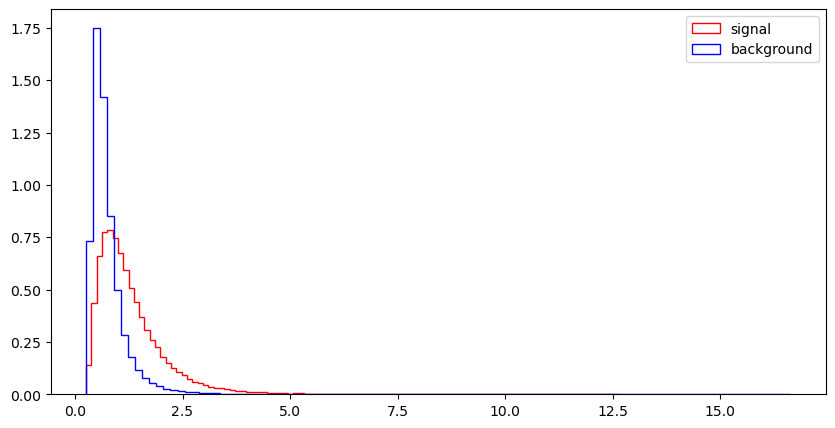

l_1_eta


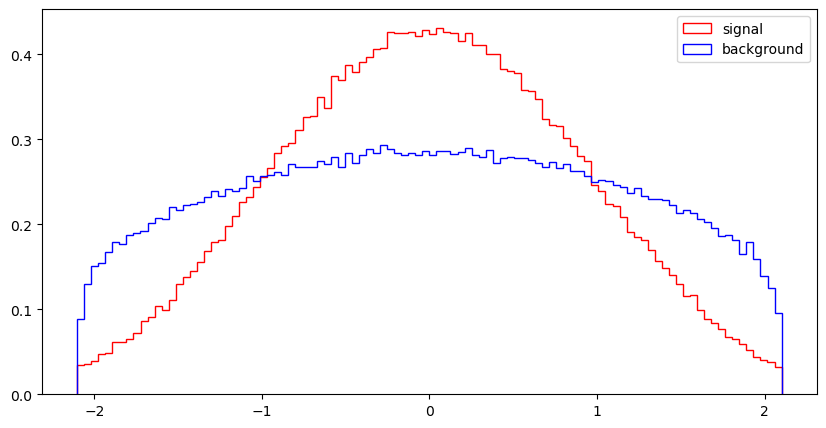

l_1_phi


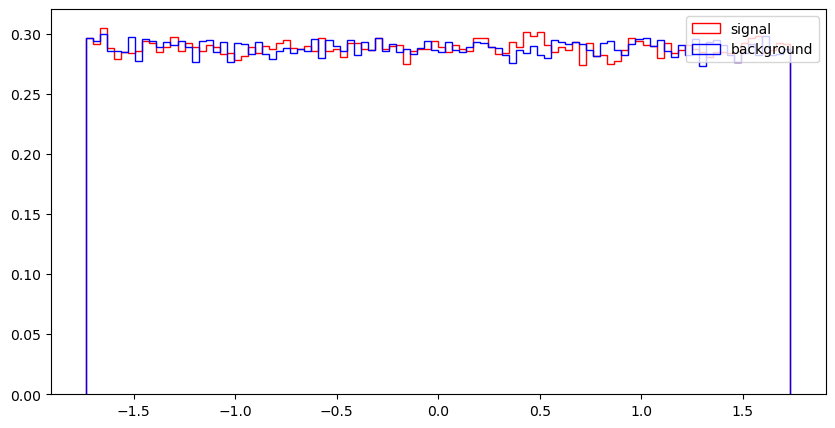

l_2_pT


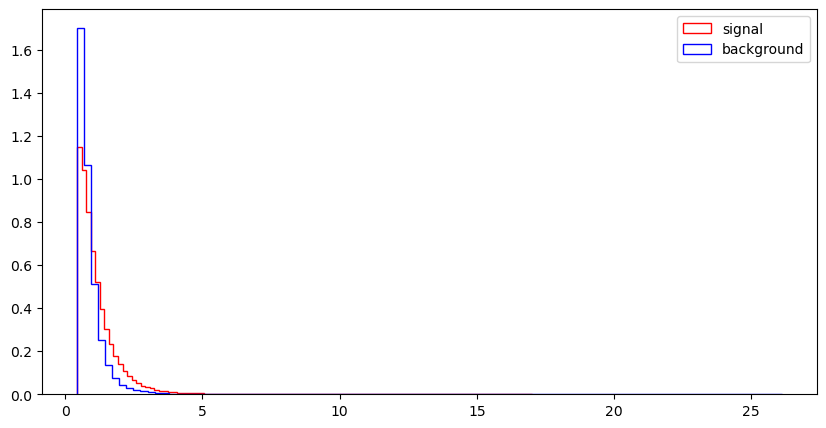

l_2_eta


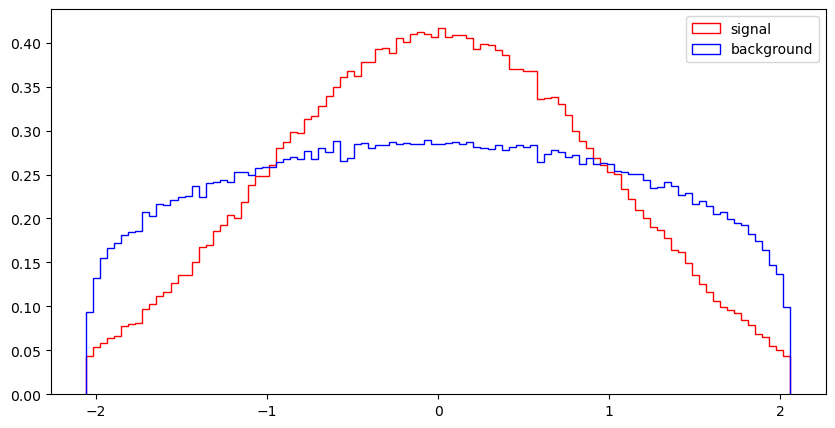

l_2_phi


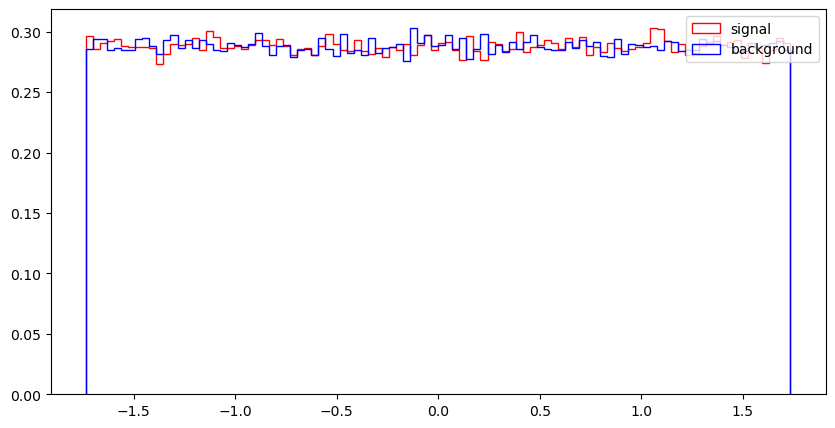

MET


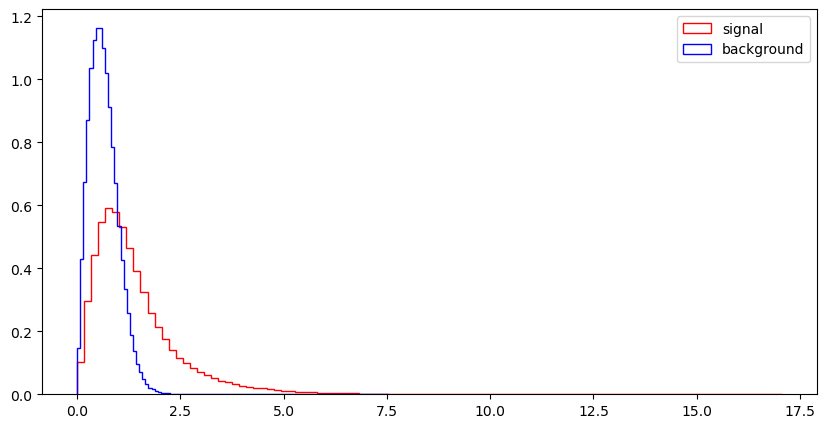

MET_phi


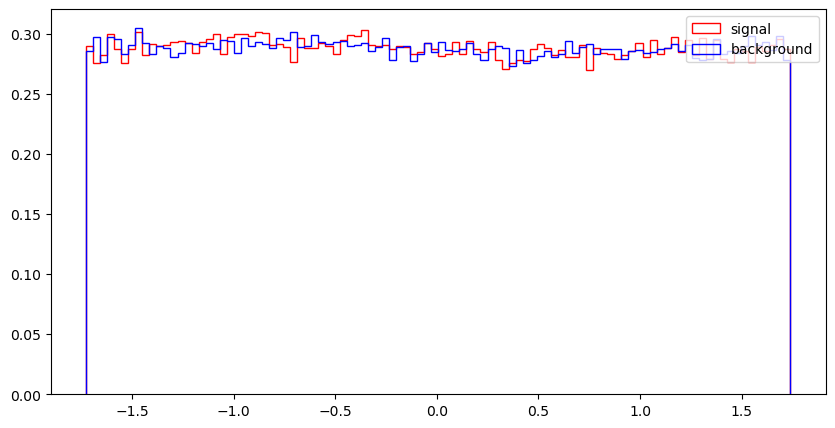

MET_rel


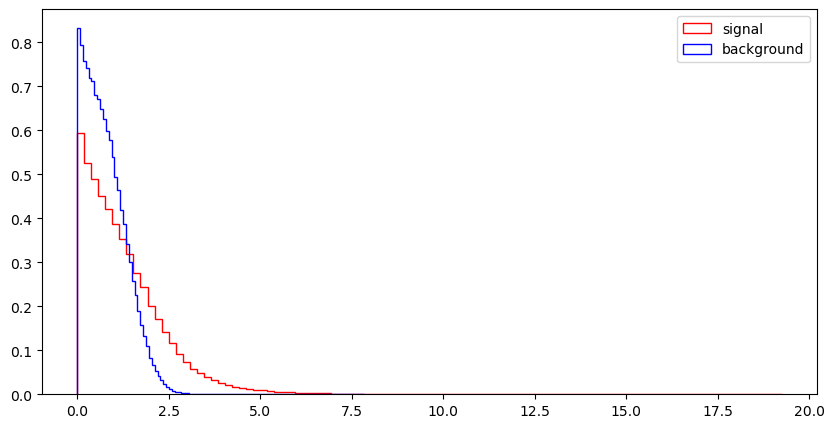

axial_MET


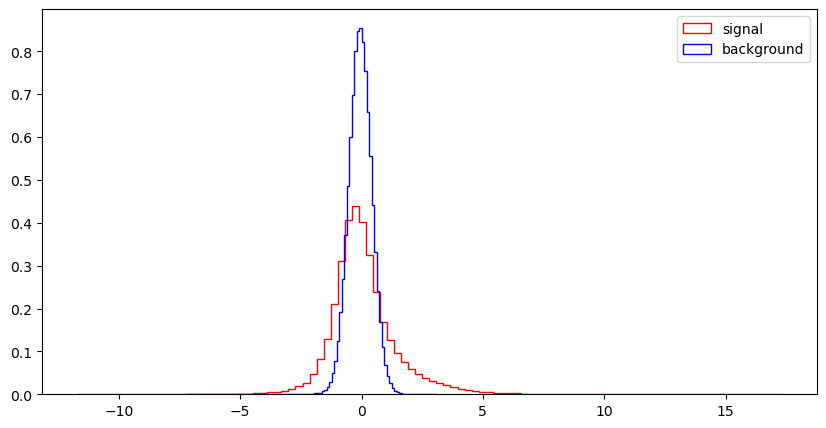

M_R


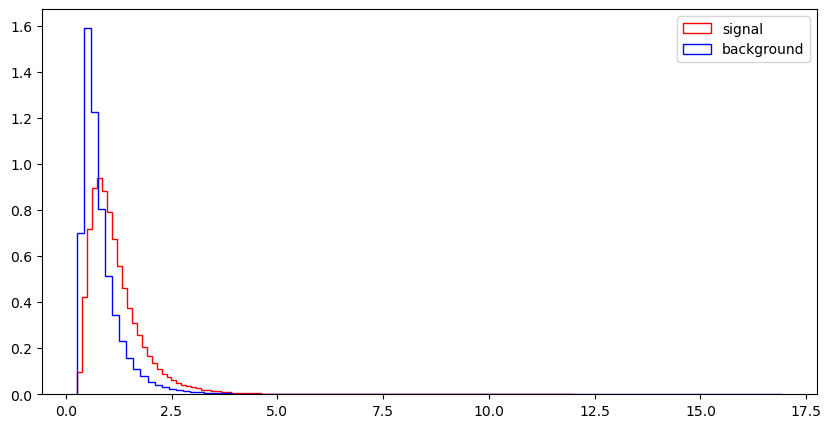

M_TR_2


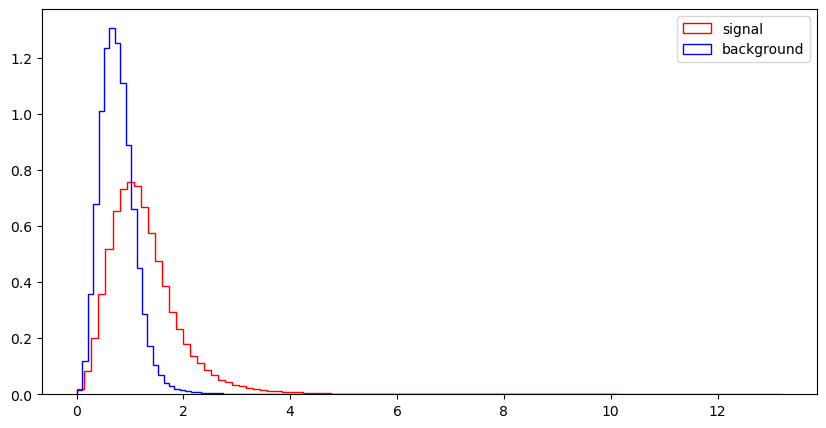

R


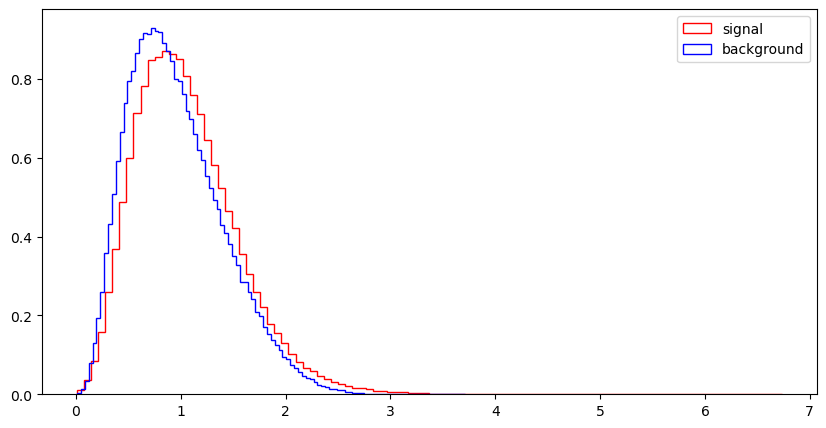

MT2


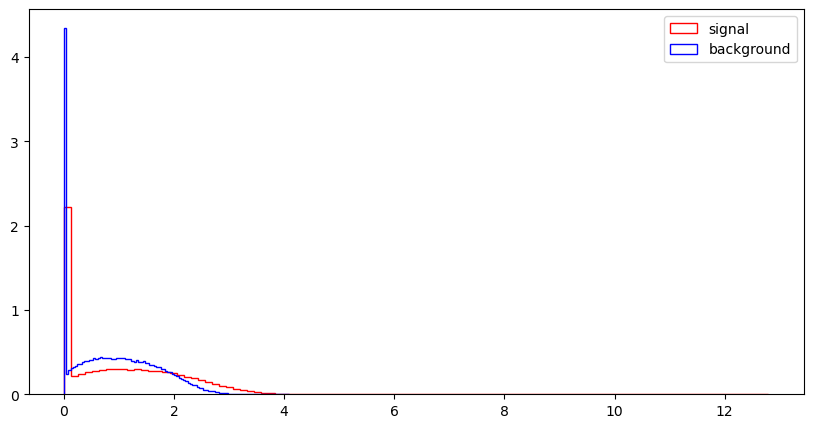

S_R


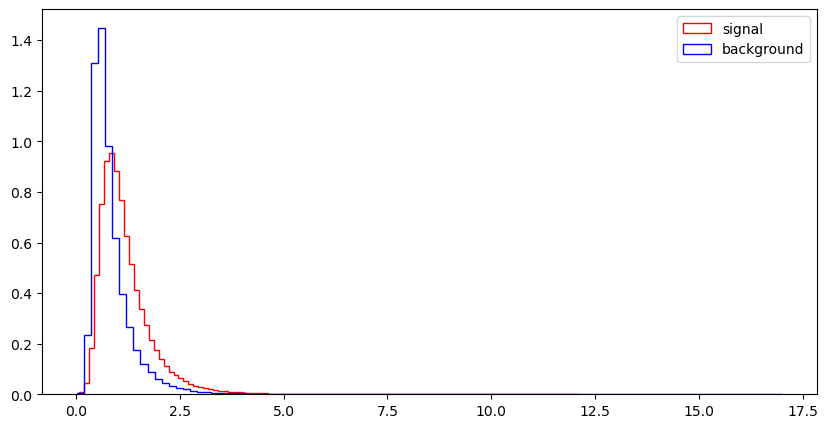

M_Delta_R


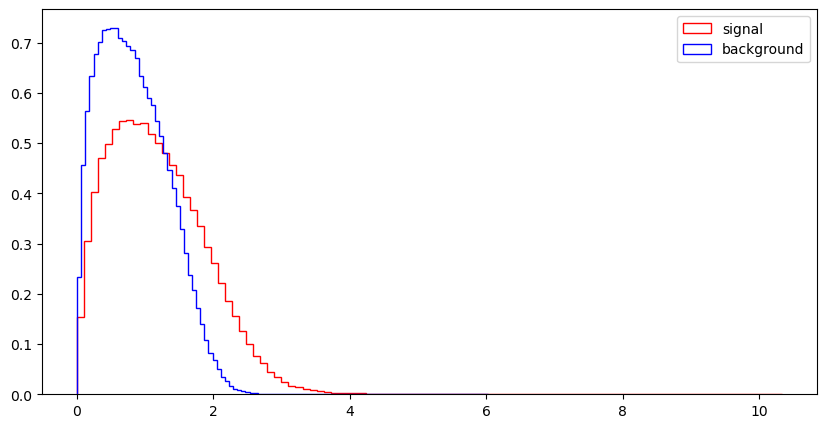

dPhi_r_b


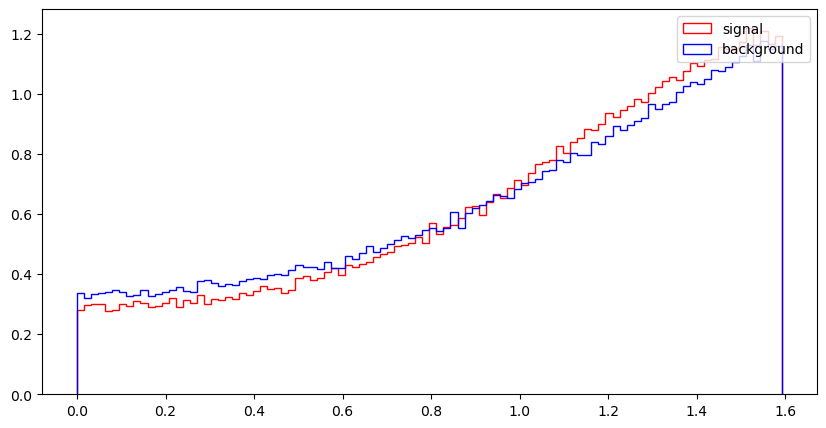

cos_theta_r1


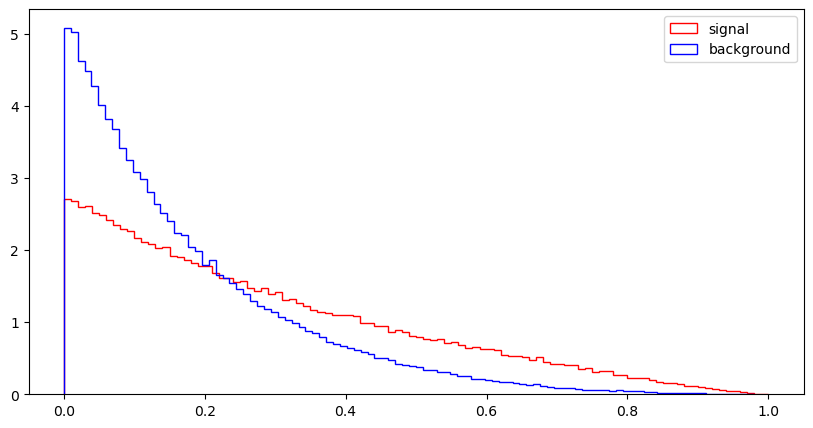

In [27]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

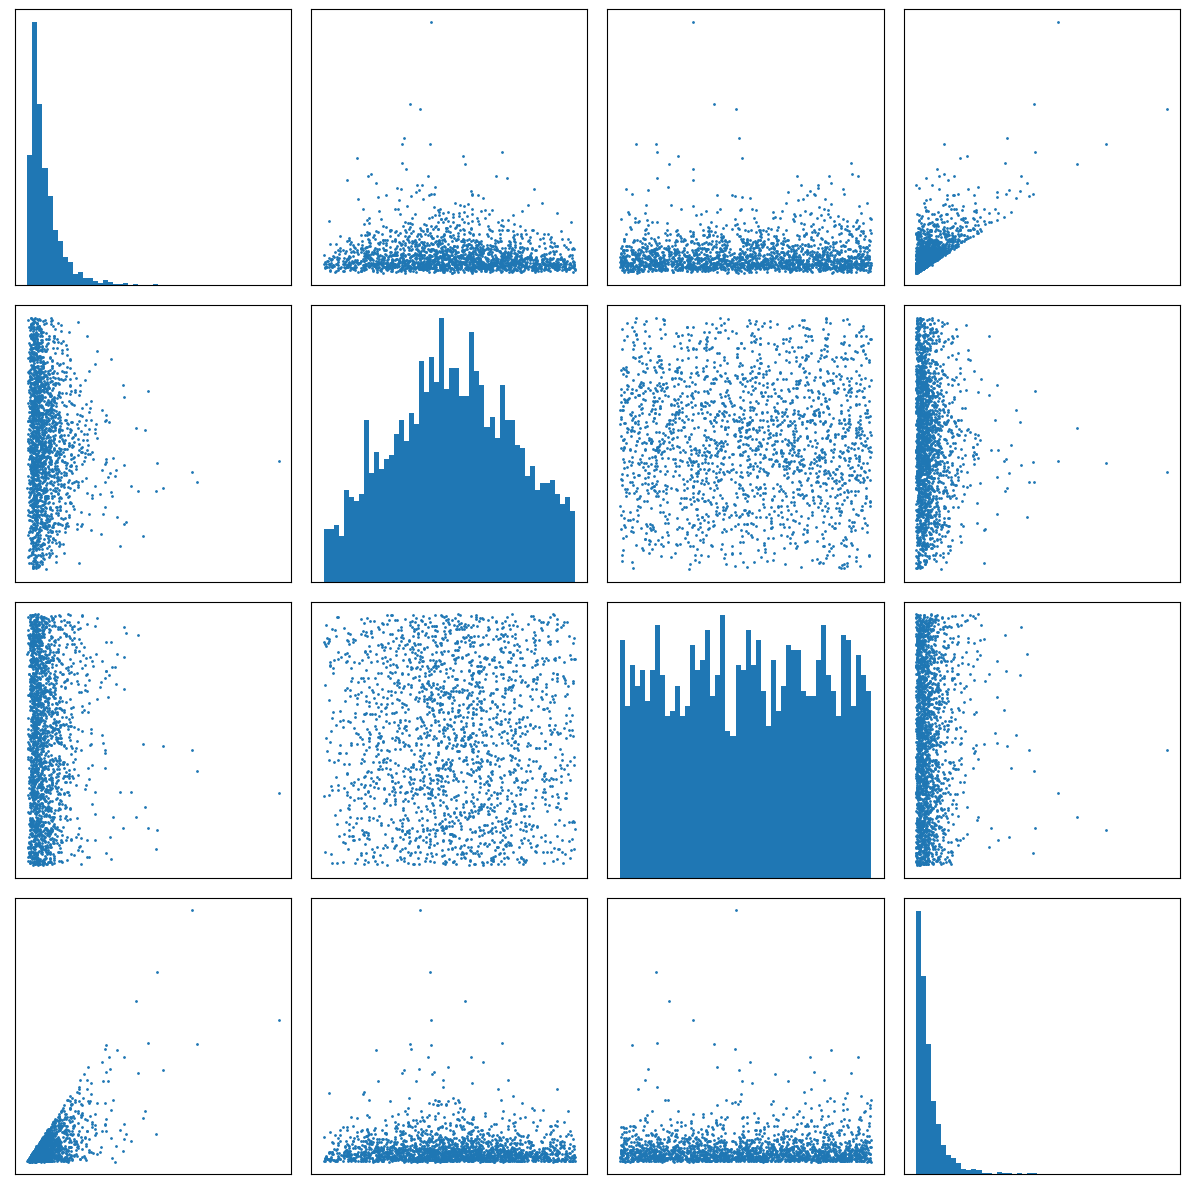

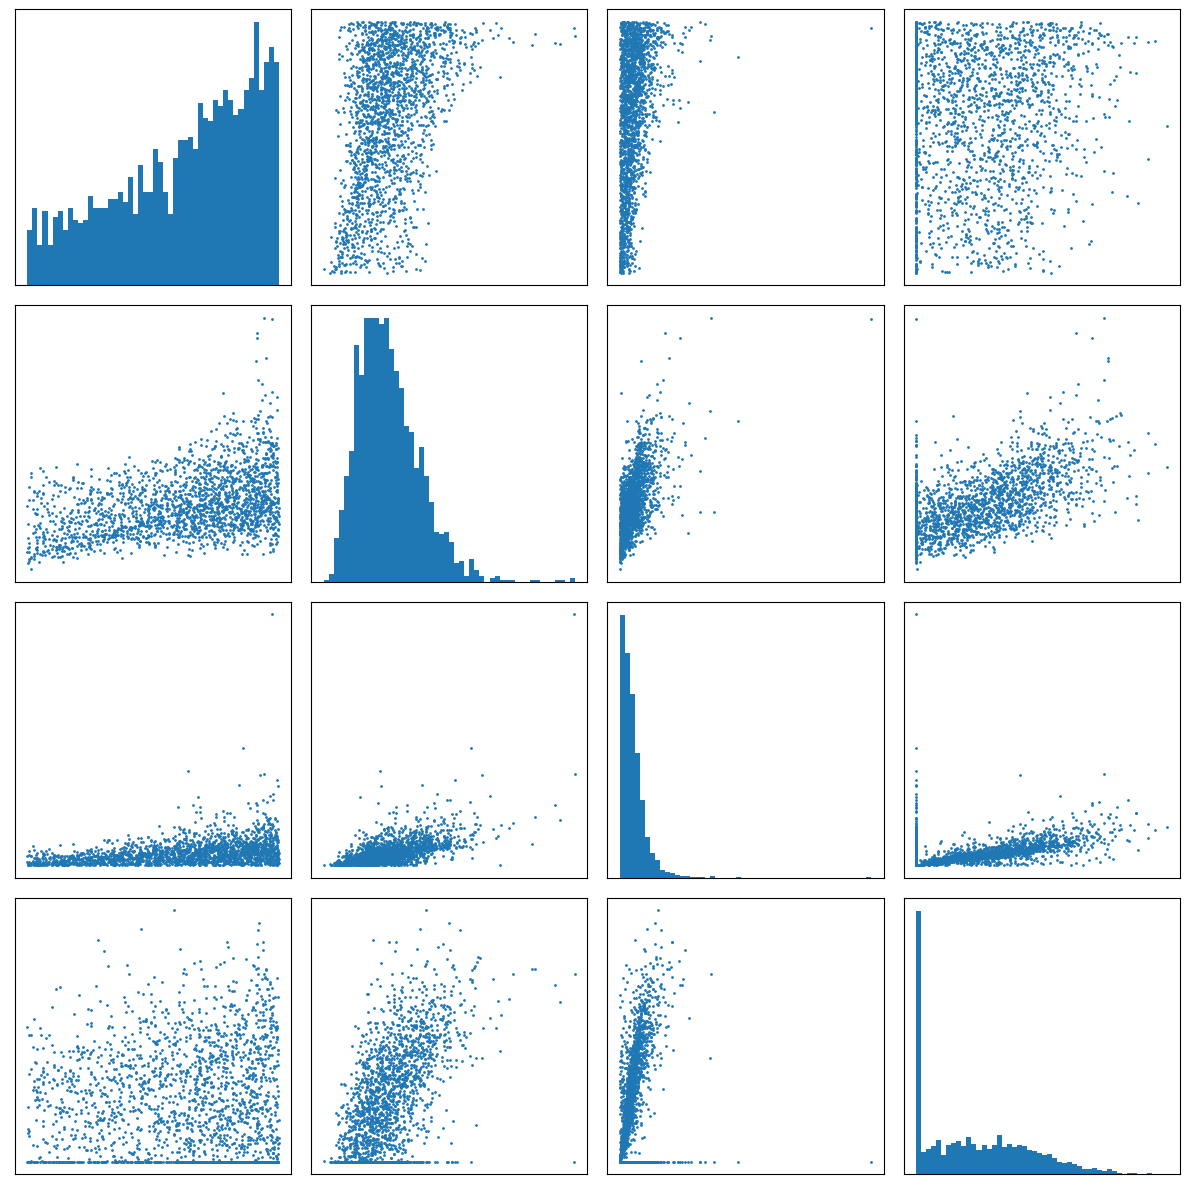

In [28]:
def pair_plot(df, variables, n_samples=2000):
    import matplotlib.pyplot as plt
    import numpy as np
    
    df_sample = df.sample(n=n_samples)
    
    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(12,12))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                axes[i,j].hist(df_sample[variables[i]], bins=50)
            else:
                axes[i,j].scatter(df_sample[variables[j]], df_sample[variables[i]], s=1)
                
            axes[i,j].set_xticks([])
            axes[i,j].set_yticks([])
    
    plt.tight_layout()
    plt.show()
pair_plot(df, RawNames[:4])
pair_plot(df, FeatureNames[:4])

In [29]:
#Pair plots were created to visualize relationships between variables. Histograms were used along the diagonal and scatter plots for variable pairs. These plots help identify correlations and patterns in both raw and high-level features.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [30]:
import numpy as np
all_data = df[VarNames[1:]]
raw_data = df[RawNames]
feature_data = df[FeatureNames]

In [31]:
cov_all = np.cov(all_data, rowvar=False)
corr_all = np.corrcoef(all_data, rowvar=False)

cov_raw = np.cov(raw_data, rowvar=False)
corr_raw = np.corrcoef(raw_data, rowvar=False)

cov_feat = np.cov(feature_data, rowvar=False)
corr_feat = np.corrcoef(feature_data, rowvar=False)

In [32]:
from IPython.display import HTML, display
import tabulate

display(HTML(tabulate.tabulate(
    corr_all,
    headers=VarNames[1:],
    tablefmt='html',
    floatfmt=".2f"
)))

l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
1.00,-0.00,0.00,0.68,-0.00,0.00,0.38,-0.00,0.16,-0.01,0.85,0.72,-0.19,-0.02,0.81,0.23,-0.16,0.16
-0.00,1.00,-0.00,-0.00,0.41,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00
0.00,-0.00,1.00,0.00,0.00,-0.27,0.00,-0.18,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
0.68,-0.00,0.00,1.00,-0.00,0.00,0.14,-0.00,-0.00,0.08,0.80,0.43,-0.32,-0.12,0.80,0.01,-0.01,-0.22
-0.00,0.41,0.00,-0.00,1.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
0.00,-0.00,-0.27,0.00,0.00,1.00,-0.00,-0.04,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00
0.38,-0.00,0.00,0.14,0.00,-0.00,1.00,-0.00,0.70,0.18,0.26,0.72,0.46,0.21,0.31,0.58,0.38,0.42
-0.00,-0.00,-0.18,-0.00,-0.00,-0.04,-0.00,1.00,-0.01,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00
0.16,-0.00,0.00,-0.00,0.00,0.00,0.70,-0.01,1.00,-0.13,0.08,0.58,0.59,0.54,0.15,0.75,0.38,0.32
-0.01,-0.00,-0.00,0.08,-0.00,-0.00,0.18,-0.00,-0.13,1.00,0.03,-0.32,-0.38,-0.54,-0.07,-0.37,-0.06,-0.27


In [33]:
display(HTML(tabulate.tabulate(
    corr_raw,
    headers=RawNames,
    tablefmt='html',
    floatfmt=".2f"
)))

l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
1.00,-0.00,0.00,0.68,-0.00,0.00,0.38,-0.00
-0.00,1.00,-0.00,-0.00,0.41,-0.00,-0.00,-0.00
0.00,-0.00,1.00,0.00,0.00,-0.27,0.00,-0.18
0.68,-0.00,0.00,1.00,-0.00,0.00,0.14,-0.00
-0.00,0.41,0.00,-0.00,1.00,0.00,0.00,-0.00
0.00,-0.00,-0.27,0.00,0.00,1.00,-0.00,-0.04
0.38,-0.00,0.00,0.14,0.00,-0.00,1.00,-0.00
-0.00,-0.00,-0.18,-0.00,-0.00,-0.04,-0.00,1.00


In [34]:
display(HTML(tabulate.tabulate(
    corr_feat,
    headers=FeatureNames,
    tablefmt='html',
    floatfmt=".2f"
)))

dPhi_r_b,R,MET_rel,MT2,S_R,cos_theta_r1,axial_MET,M_R,M_TR_2,M_Delta_R
1.00,0.42,0.38,0.06,-0.01,0.11,-0.06,-0.11,0.23,0.16
0.42,1.00,0.59,0.57,-0.29,0.63,-0.38,-0.38,0.38,0.56
0.38,0.59,1.00,0.54,0.15,0.32,-0.13,0.08,0.58,0.75
0.06,0.57,0.54,1.00,-0.02,0.26,-0.54,-0.07,0.38,0.81
-0.01,-0.29,0.15,-0.02,1.00,-0.09,-0.07,0.98,0.64,0.25
0.11,0.63,0.32,0.26,-0.09,1.00,-0.27,-0.12,0.45,0.32
-0.06,-0.38,-0.13,-0.54,-0.07,-0.27,1.00,0.03,-0.32,-0.37
-0.11,-0.38,0.08,-0.07,0.98,-0.12,0.03,1.00,0.58,0.19
0.23,0.38,0.58,0.38,0.64,0.45,-0.32,0.58,1.00,0.67
0.16,0.56,0.75,0.81,0.25,0.32,-0.37,0.19,0.67,1.00


Hint: Example code for embedding a `tabulate` table into a notebook:

In [35]:
!pip install tabulate --break-system-packages

In [36]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [37]:
def compute_efficiencies(df, var, thresholds):
    import numpy as np
    
    signal = df[df.signal == 1][var]
    background = df[df.signal == 0][var]
    
    tpr = []
    fpr = []
    
    for xc in thresholds:
        tpr.append(np.sum(signal > xc) / len(signal))
        fpr.append(np.sum(background > xc) / len(background))
    
    return np.array(tpr), np.array(fpr)

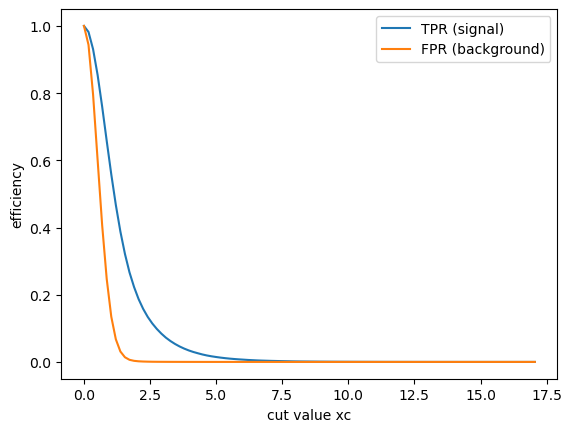

In [38]:
import matplotlib.pyplot as plt
import numpy as np

var = "MET"

thresholds = np.linspace(df[var].min(), df[var].max(), 100)

tpr, fpr = compute_efficiencies(df, var, thresholds)

plt.plot(thresholds, tpr, label="TPR (signal)")
plt.plot(thresholds, fpr, label="FPR (background)")
plt.xlabel("cut value xc")
plt.ylabel("efficiency")
plt.legend()
plt.show()

In [39]:
#The TPR and FPR were computed as a function of the cut value. Signal efficiency decreases as the cut becomes more strict, while background rejection improves.

In [40]:
def compute_significance(tpr, fpr, NS, NB):
    NS_prime = tpr * NS
    NB_prime = fpr * NB
    
    return NS_prime / np.sqrt(NS_prime + NB_prime)

/tmp/ipykernel_2155/1537324714.py:5: RuntimeWarning: invalid value encountered in divide
  return NS_prime / np.sqrt(NS_prime + NB_prime)


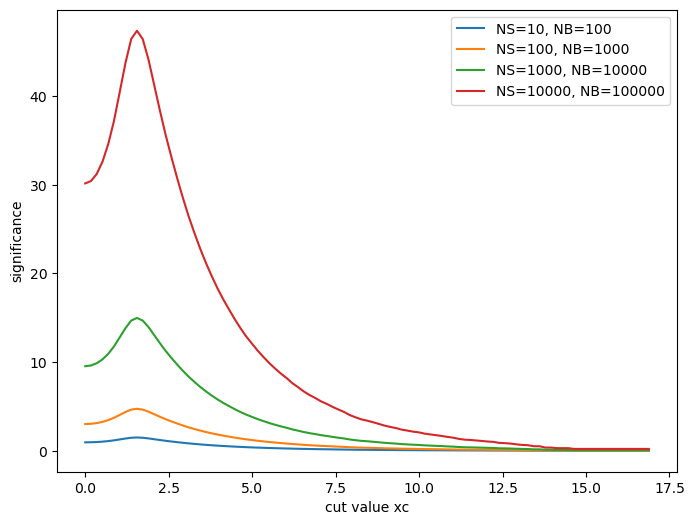

In [41]:
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

var = "MET"
thresholds = np.linspace(df[var].min(), df[var].max(), 100)

tpr, fpr = compute_efficiencies(df, var, thresholds)

plt.figure(figsize=(8,6))

for NS, NB in scenarios:
    sig = compute_significance(tpr, fpr, NS, NB)
    plt.plot(thresholds, sig, label=f"NS={NS}, NB={NB}")

plt.xlabel("cut value xc")
plt.ylabel("significance")
plt.legend()
plt.show()

In [42]:
#The significance varies with the cut value and depends strongly on the expected signal and background yields. Larger datasets lead to higher achievable significance.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [43]:
vars_selected = ["MET", "MT2", "M_R"]
cuts = {
    "MET": 1.0,
    "MT2": 0.8,
    "M_R": 1.0
}
#The observables MET, MT2, and M_R were selected based on their strong separation power. Cut values were chosen near the maxima of the significance curves.

In [44]:
def cut_flow(df, cuts, NS, NB):
    import numpy as np
    
    df_cut = df.copy()
    
    results = []
    total_sig = len(df[df.signal == 1])
    total_bkg = len(df[df.signal == 0])
    
    for var, xc in cuts.items():
        df_cut = df_cut[df_cut[var] > xc]
        sig = len(df_cut[df_cut.signal == 1])
        bkg = len(df_cut[df_cut.signal == 0])
        eps_S = sig / total_sig
        eps_B = bkg / total_bkg
        
        NS_prime = eps_S * NS
        NB_prime = eps_B * NB
        
        sigma = NS_prime / np.sqrt(NS_prime + NB_prime) if (NS_prime + NB_prime) > 0 else 0
        
        results.append([var, eps_S, eps_B, NS_prime, NB_prime, sigma])
    
    return results

cuts = {"MET": 1.0, "MT2": 0.8, "M_R": 1.0}

results = cut_flow(df, cuts, NS=100, NB=1000)

In [45]:
from IPython.display import HTML, display
import tabulate

display(HTML(tabulate.tabulate(
    results,
    headers=["Cut", "εS", "εB", "N'S", "N'B", "σ"],
    tablefmt='html',
    floatfmt=".3f"
)))

scenarios = [(10,100), (100,1000), (1000,10000), (10000,100000)]

for NS, NB in scenarios:
    print(f"Scenario: NS={NS}, NB={NB}")
    results = cut_flow(df, cuts, NS, NB)
    display(HTML(tabulate.tabulate(
        results,
        headers=["Cut", "εS", "εB", "N'S", "N'B", "σ"],
        tablefmt='html',
        floatfmt=".3f"
    )))

Cut,εS,εB,N'S,N'B,σ
MET,0.577,0.153,57.690,152.828,3.976
MT2,0.344,0.130,34.357,130.110,2.679
M_R,0.176,0.033,17.582,32.823,2.476


Scenario: NS=10, NB=100


Cut,εS,εB,N'S,N'B,σ
MET,0.577,0.153,5.769,15.283,1.257
MT2,0.344,0.130,3.436,13.011,0.847
M_R,0.176,0.033,1.758,3.282,0.783


Scenario: NS=100, NB=1000


Cut,εS,εB,N'S,N'B,σ
MET,0.577,0.153,57.690,152.828,3.976
MT2,0.344,0.130,34.357,130.110,2.679
M_R,0.176,0.033,17.582,32.823,2.476


Scenario: NS=1000, NB=10000


Cut,εS,εB,N'S,N'B,σ
MET,0.577,0.153,576.902,1528.282,12.574
MT2,0.344,0.130,343.571,1301.102,8.472
M_R,0.176,0.033,175.821,328.230,7.831


Scenario: NS=10000, NB=100000


Cut,εS,εB,N'S,N'B,σ
MET,0.577,0.153,5769.024,15282.820,39.761
MT2,0.344,0.130,3435.713,13011.025,26.790
M_R,0.176,0.033,1758.206,3282.303,24.765


In [47]:
("MET", "M_R")
df1 = df[df["MET"] > 1.0]
df2 = df[df["M_R"] > 1.0]

#Correlated variables reduce the effectiveness of multiple cuts because they carry similar information. Changing the order of cuts affects the final significance, showing that selection order matters.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [48]:
X = df[VarNames[1:]].values  
y = df["signal"].values      

In [49]:
X_sig = X[y == 1]
X_bkg = X[y == 0]

In [50]:
m1 = np.mean(X_bkg, axis=0)
m2 = np.mean(X_sig, axis=0)

In [51]:
diff = (m2 - m1).reshape(-1, 1)
S_B = diff @ diff.T

In [52]:
S_W = np.zeros((X.shape[1], X.shape[1]))

for x in X_sig:
    d = (x - m2).reshape(-1,1)
    S_W += d @ d.T

for x in X_bkg:
    d = (x - m1).reshape(-1,1)
    S_W += d @ d.T

In [53]:
w = np.linalg.inv(S_W) @ (m2 - m1)

In [54]:
F_sig = X_sig @ w
F_bkg = X_bkg @ w

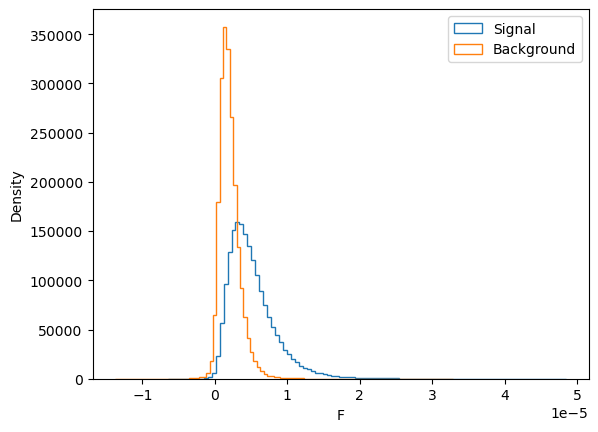

In [55]:
import matplotlib.pyplot as plt

plt.hist(F_sig, bins=100, density=True, histtype='step', label='Signal')
plt.hist(F_bkg, bins=100, density=True, histtype='step', label='Background')

plt.xlabel("F")
plt.ylabel("Density")
plt.legend()
plt.show()

In [56]:
# The linear discriminant combines multiple observables into a single variable that enhances the separation between signal and background. The resulting distributions show improved separation compared to individual variables.

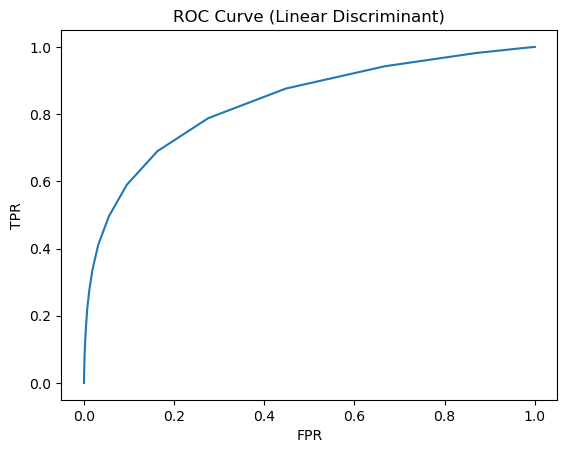

In [57]:
def compute_roc(F_sig, F_bkg, thresholds):
    tpr = []
    fpr = []
    
    for xc in thresholds:
        tpr.append(np.sum(F_sig > xc) / len(F_sig))
        fpr.append(np.sum(F_bkg > xc) / len(F_bkg))
    
    return np.array(tpr), np.array(fpr)
thresholds = np.linspace(min(F_bkg.min(), F_sig.min()),
                         max(F_bkg.max(), F_sig.max()), 100)

tpr, fpr = compute_roc(F_sig, F_bkg, thresholds)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Linear Discriminant)")
plt.show()

In [59]:
tpr, fpr = compute_roc(F_sig, F_bkg, thresholds)

import numpy as np

scenarios = [(10,100), (100,1000), (1000,10000), (10000,100000)]

for NS, NB in scenarios:
    sig = significance(tpr, fpr, NS, NB)
    
    max_sig = np.max(sig)
    best_idx = np.argmax(sig)
    best_cut = thresholds[best_idx]
    
    print(f"NS={NS}, NB={NB}")
    print(f"Max significance: {max_sig:.3f}")
    print(f"Best cut value: {best_cut:.3f}")
    print("------")

NS=10, NB=100
Max significance: nan
Best cut value: 0.000
------
NS=100, NB=1000
Max significance: nan
Best cut value: 0.000
------
NS=1000, NB=10000
Max significance: nan
Best cut value: 0.000
------
NS=10000, NB=100000
Max significance: nan
Best cut value: 0.000
------


/tmp/ipykernel_2155/1809167316.py:4: RuntimeWarning: invalid value encountered in divide
  return NS_p / np.sqrt(NS_p + NB_p)


In [ ]:
# As the number of signal and background events increases, the achievable significance also increases. The linear discriminant consistently provides improved performance by maximizing separation between the two classes.